E0000 00:00:1787040289.229291   32672 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.4136 - val_loss: 0.3443
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.3290 - val_loss: 0.3210
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.3129 - val_loss: 0.3096
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.3030 - val_loss: 0.3013
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2966 - val_loss: 0.2964
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2926 - val_loss: 0.2933
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2901 - val_loss: 0.2912
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2884 - val_loss: 0.2899
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2873 - val_loss: 0.2890
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2866 - val_loss: 0.2884
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2858 - val_loss: 0.2876
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/st

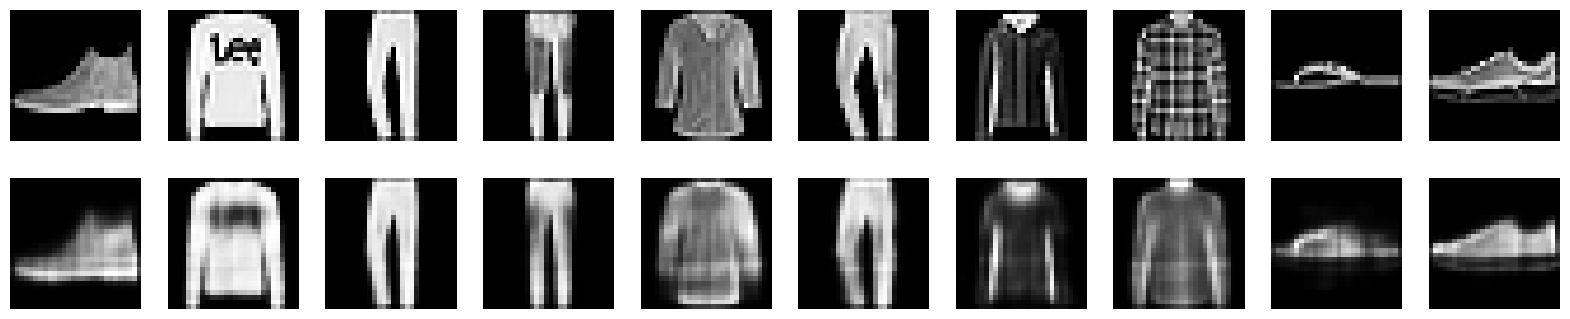

In [2]:
"""
1. Vanilla Autoencoder
Vanilla Autoencoder are the simplest form used for unsupervised learning tasks. They consist of two main parts an encoder that compresses the input data
into a smaller, dense representation and a decoder that reconstructs the original input from this compressed form.
Training minimizes reconstruction error which measures the difference between input and output. This optimization is done via backpropagation which helps
in updating the network weights to improve reconstruction accuracy.
They are foundational models helps in serving as building blocks for more complex variants.
"""

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

# if steel have not downloaded dataset uncomment and use this
# (x_train, _), (x_test, _) = fashion_mnist.load_data()
# x_train = x_train.astype('float32') / 255.
# x_test = x_test.astype('float32') / 255.

# x_train_flat = x_train.reshape(len(x_train), 784)
# x_test_flat = x_test.reshape(len(x_test), 784)
import os
import idx2numpy

data_dir = "./data/FashionMNIST/raw/"

x_train = idx2numpy.convert_from_file(os.path.join(data_dir, "train-images-idx3-ubyte"))
x_test  = idx2numpy.convert_from_file(os.path.join(data_dir, "t10k-images-idx3-ubyte"))

x_train = x_train.astype('float32') / 255.
x_test  = x_test.astype('float32') / 255.

x_train_flat = x_train.reshape(len(x_train), 784)
x_test_flat  = x_test.reshape(len(x_test), 784)

n = 10 
encoding_dim = 32
input_img = tf.keras.Input(shape=(784,))
encoded = tf.keras.layers.Dense(encoding_dim, activation='relu')(input_img)
decoded = tf.keras.layers.Dense(784, activation='sigmoid')(encoded)

autoencoder = tf.keras.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.fit(x_train_flat, x_train_flat,
                epochs=50,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test_flat, x_test_flat))

decoded_imgs = autoencoder.predict(x_test_flat)

plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_flat[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.show()

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.4189 - val_loss: 0.3492
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.3312 - val_loss: 0.3209
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3125 - val_loss: 0.3093
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3033 - val_loss: 0.3022
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2974 - val_loss: 0.2975
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2938 - val_loss: 0.2948
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2917 - val_loss: 0.2930
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2903 - val_loss: 0.2919
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2892 - val_loss: 0.2910
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2881 - val_loss: 0.2898
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2874 - val_loss: 0.2893
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step

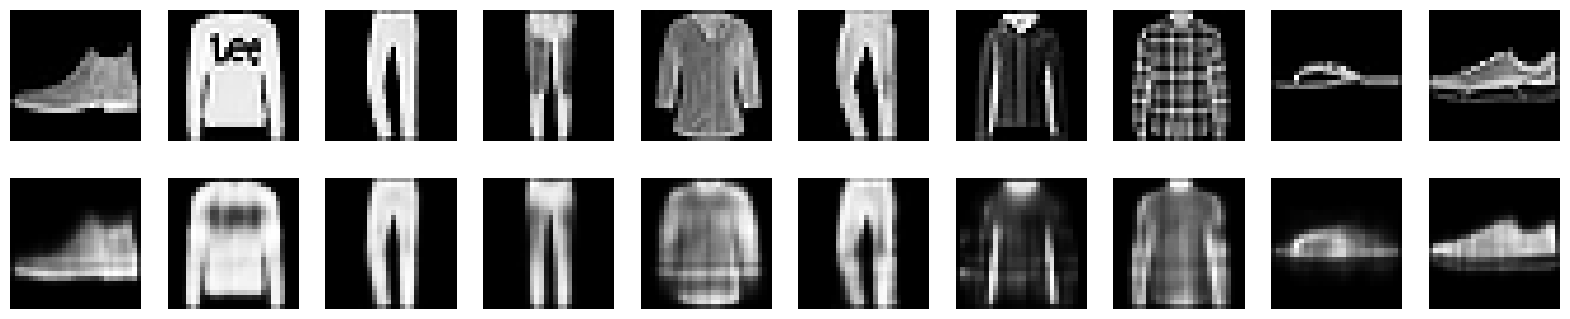

In [3]:
"""
2. Sparse Autoencoder
Sparse Autoencoder add sparsity constraints that encourage only a small subset of neurons in the hidden layer to activate at once helps in creating
a more efficient and focused representation.
Unlike vanilla models, they include regularization methods like L1 penalty and dropout to enforce sparsity.
KL Divergence is used to maintain the sparsity level by matching the latent distribution to a predefined sparse target.
This selective activation helps in feature selection and learning meaningful patterns while ignoring irrelevant noise.
"""

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

# if steel have not downloaded dataset uncomment and use this

# (x_train, _), (x_test, _) = fashion_mnist.load_data()
# x_train = x_train.astype('float32') / 255.
# x_test = x_test.astype('float32') / 255.

# x_train_flat = x_train.reshape(len(x_train), 784)
# x_test_flat = x_test.reshape(len(x_test), 784)

import os
import idx2numpy

data_dir = "./data/FashionMNIST/raw/"

x_train = idx2numpy.convert_from_file(os.path.join(data_dir, "train-images-idx3-ubyte"))
x_test  = idx2numpy.convert_from_file(os.path.join(data_dir, "t10k-images-idx3-ubyte"))

x_train = x_train.astype('float32') / 255.
x_test  = x_test.astype('float32') / 255.

x_train_flat = x_train.reshape(len(x_train), 784)
x_test_flat  = x_test.reshape(len(x_test), 784)

n = 10 
encoding_dim = 32
input_img = tf.keras.Input(shape=(784,))
encoded = tf.keras.layers.Dense(encoding_dim, activation='relu',
                                activity_regularizer=tf.keras.regularizers.l1(1e-5))(input_img)
decoded = tf.keras.layers.Dense(784, activation='sigmoid')(encoded)

sparse_autoencoder = tf.keras.Model(input_img, decoded)
sparse_autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

sparse_autoencoder.fit(x_train_flat, x_train_flat,
                      epochs=50,
                      batch_size=256,
                      shuffle=True,
                      validation_data=(x_test_flat, x_test_flat))

decoded_imgs = sparse_autoencoder.predict(x_test_flat)

plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_flat[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.show()

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.4355 - val_loss: 0.3653
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.3466 - val_loss: 0.3385
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.3312 - val_loss: 0.3303
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3247 - val_loss: 0.3252
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3205 - val_loss: 0.3216
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3175 - val_loss: 0.3188
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3148 - val_loss: 0.3163
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3126 - val_loss: 0.3143
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3109 - val_loss: 0.3129
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3094 - val_loss: 0.3114
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3082 - val_loss: 0.3105
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

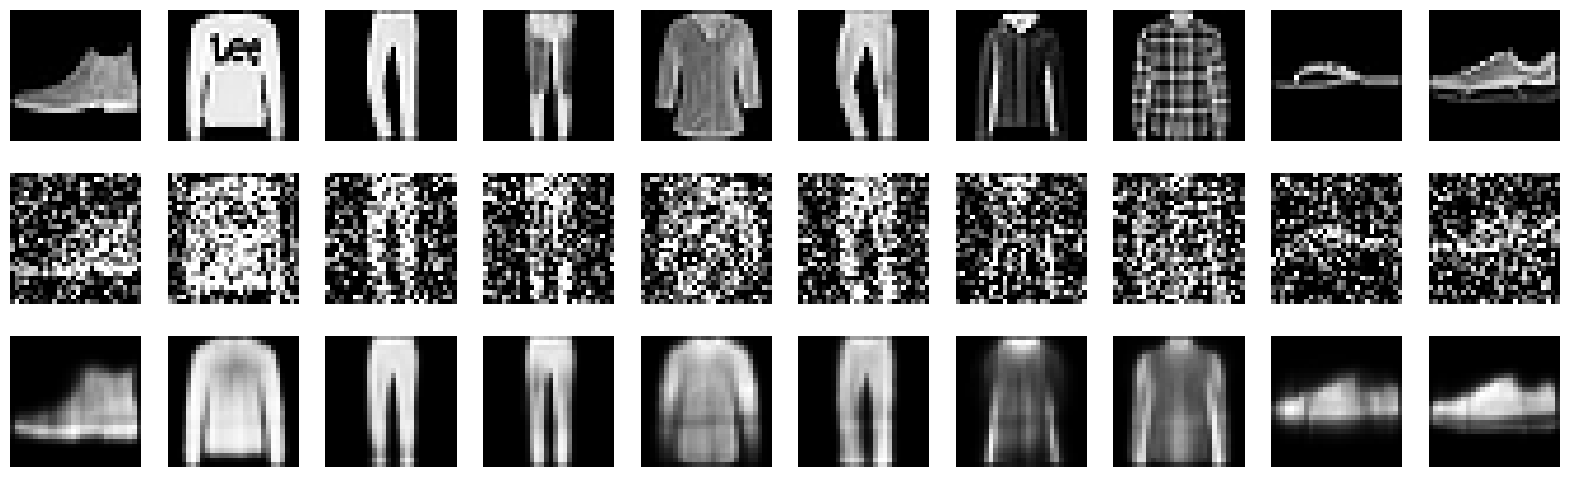

In [4]:
"""
3. Denoising Autoencoder
Denoising Autoencoders are designed to handle corrupted or noisy inputs by learning to reconstruct the clean, original data.
Training involves feeding intentionally corrupted inputs and minimizing the reconstruction error against the clean version.
This approach forces the model to capture robust features that are invariant to noise.
"""

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

# if steel have not downloaded dataset uncomment and use this

# (x_train, _), (x_test, _) = fashion_mnist.load_data()
# x_train = x_train.astype('float32') / 255.
# x_test = x_test.astype('float32') / 255.

# x_train_flat = x_train.reshape(len(x_train), 784)
# x_test_flat = x_test.reshape(len(x_test), 784)

import os
import idx2numpy

data_dir = "./data/FashionMNIST/raw/"

x_train = idx2numpy.convert_from_file(os.path.join(data_dir, "train-images-idx3-ubyte"))
x_test  = idx2numpy.convert_from_file(os.path.join(data_dir, "t10k-images-idx3-ubyte"))

x_train = x_train.astype('float32') / 255.
x_test  = x_test.astype('float32') / 255.

x_train_flat = x_train.reshape(len(x_train), 784)
x_test_flat  = x_test.reshape(len(x_test), 784)

n = 10
encoding_dim = 32
input_img = tf.keras.Input(shape=(784,))
encoded = tf.keras.layers.Dense(encoding_dim, activation='relu')(input_img)
decoded = tf.keras.layers.Dense(784, activation='sigmoid')(encoded)

denoising_autoencoder = tf.keras.Model(input_img, decoded)
denoising_autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

noise_factor = 0.5
x_train_noisy = x_train_flat + noise_factor * \
    np.random.normal(loc=0.0, scale=1.0, size=x_train_flat.shape)
x_test_noisy = x_test_flat + noise_factor * \
    np.random.normal(loc=0.0, scale=1.0, size=x_test_flat.shape)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

denoising_autoencoder.fit(x_train_noisy, x_train_flat,
                          epochs=50,
                          batch_size=256,
                          shuffle=True,
                          validation_data=(x_test_noisy, x_test_flat))

decoded_imgs = denoising_autoencoder.predict(x_test_noisy)

plt.figure(figsize=(20, 6))
for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_flat[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.show()

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.4394 - val_loss: 0.3555
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3399 - val_loss: 0.3308
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3231 - val_loss: 0.3204
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3144 - val_loss: 0.3132
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3085 - val_loss: 0.3081
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3044 - val_loss: 0.3049
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3019 - val_loss: 0.3032
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3006 - val_loss: 0.3022
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2998 - val_loss: 0.3015
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2993 - val_loss: 0.3012
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2989 - val_loss: 0.3008
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

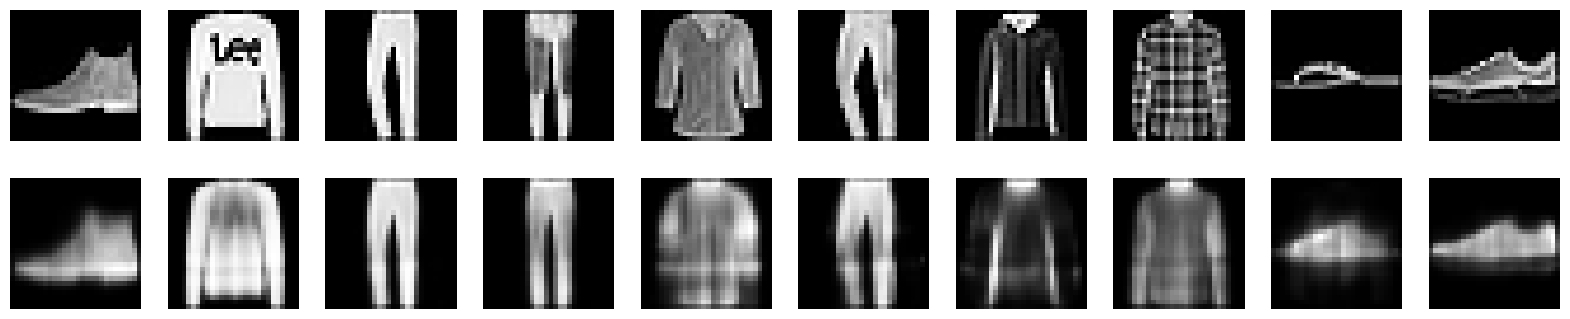

In [5]:
"""
4. Undercomplete Autoencoder
Undercomplete Autoencoders intentionally restrict the size of the hidden layer to be smaller than the input layer.
This bottleneck forces the model to compress the data helps in learning only the most significant features and discarding redundant information.
The model is trained by minimizing the reconstruction error while ensuring the latent space remains compact.
"""

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

# if steel have not downloaded dataset uncomment and use this

# (x_train, _), (x_test, _) = fashion_mnist.load_data()
# x_train = x_train.astype('float32') / 255.
# x_test = x_test.astype('float32') / 255.

# x_train_flat = x_train.reshape(len(x_train), 784)
# x_test_flat = x_test.reshape(len(x_test), 784)

import os
import idx2numpy

data_dir = "./data/FashionMNIST/raw/"

x_train = idx2numpy.convert_from_file(os.path.join(data_dir, "train-images-idx3-ubyte"))
x_test  = idx2numpy.convert_from_file(os.path.join(data_dir, "t10k-images-idx3-ubyte"))

x_train = x_train.astype('float32') / 255.
x_test  = x_test.astype('float32') / 255.

x_train_flat = x_train.reshape(len(x_train), 784)
x_test_flat  = x_test.reshape(len(x_test), 784)

n = 10 
encoding_dim = 16 
input_img = tf.keras.Input(shape=(784,))
encoded = tf.keras.layers.Dense(encoding_dim, activation='relu')(input_img)
decoded = tf.keras.layers.Dense(784, activation='sigmoid')(encoded)

undercomplete_autoencoder = tf.keras.Model(input_img, decoded)
undercomplete_autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

undercomplete_autoencoder.fit(x_train_flat, x_train_flat,
                             epochs=50,
                             batch_size=256,
                             shuffle=True,
                             validation_data=(x_test_flat, x_test_flat))

decoded_imgs = undercomplete_autoencoder.predict(x_test_flat)

plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_flat[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.show()

Epoch 1/10
  1/235 ━━━━━━━━━━━━━━━━━━━━ 6:26 2s/step - contractive_loss: 3.2903 - loss: 0.6968 - reconstruction_loss: 0.6965

E0000 00:00:1787041972.861193   32672 util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


235/235 ━━━━━━━━━━━━━━━━━━━━ 18s 71ms/step - contractive_loss: 0.1041 - loss: 0.4700 - reconstruction_loss: 0.4700
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 16s 68ms/step - contractive_loss: 0.3247 - loss: 0.4392 - reconstruction_loss: 0.4392
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 16s 69ms/step - contractive_loss: 0.4627 - loss: 0.4209 - reconstruction_loss: 0.4208
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 16s 68ms/step - contractive_loss: 0.6194 - loss: 0.4067 - reconstruction_loss: 0.4067
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 15s 66ms/step - contractive_loss: 0.8100 - loss: 0.3816 - reconstruction_loss: 0.3815
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 15s 65ms/step - contractive_loss: 1.0085 - loss: 0.3722 - reconstruction_loss: 0.3721
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 16s 70ms/step - contractive_loss: 0.9900 - loss: 0.3753 - reconstruction_loss: 0.3752
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 16s 69ms/step - contractive_loss: 0.9474 - loss: 0.3558 - reconstruction_loss: 0.3557
Epo

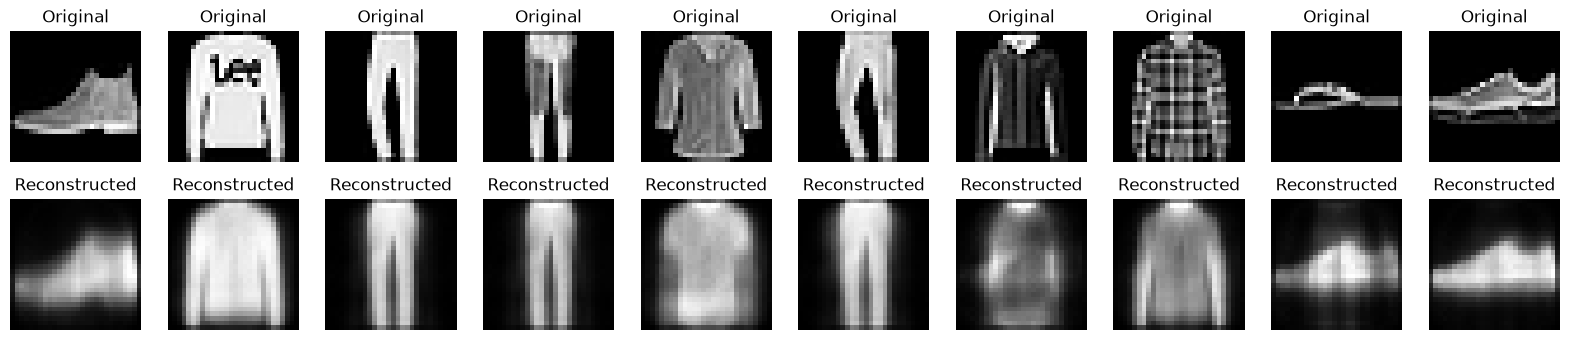

In [8]:
"""
5. Contractive Autoencoder
Contractive Autoencoders introduce an additional penalty during training to make the learned representations robust to small changes in input data.
They minimize both reconstruction error and a regularization term that penalizes sensitivity to input perturbations.
This results in stable, invariant features useful in noisy or fluctuating environments.
"""

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

# if steel have not downloaded dataset uncomment and use this

# (x_train, _), (x_test, _) = fashion_mnist.load_data()
# x_train = x_train.astype('float32') / 255.
# x_test = x_test.astype('float32') / 255.

# x_train_flat = x_train.reshape(len(x_train), 784)
# x_test_flat = x_test.reshape(len(x_test), 784)

import os
import idx2numpy

data_dir = "./data/FashionMNIST/raw/"

x_train = idx2numpy.convert_from_file(os.path.join(data_dir, "train-images-idx3-ubyte"))
x_test  = idx2numpy.convert_from_file(os.path.join(data_dir, "t10k-images-idx3-ubyte"))

x_train = x_train.astype('float32') / 255.
x_test  = x_test.astype('float32') / 255.

x_train_flat = x_train.reshape(len(x_train), 784)
x_test_flat  = x_test.reshape(len(x_test), 784)

class ContractiveAutoencoder(tf.keras.Model):

    def __init__(self, encoding_dim=32, lambda_=1e-4):
        super().__init__()

        self.lambda_ = lambda_

        # Encoder
        self.encoder = tf.keras.layers.Dense(
            encoding_dim,
            activation="sigmoid"
        )

        # Decoder
        self.decoder = tf.keras.layers.Dense(
            784,
            activation="sigmoid"
        )

    def call(self, x):
        z = self.encoder(x)
        return self.decoder(z)

    def train_step(self, data):

        x = data[0]

        # =================================================
        # Tape for calculating final gradients
        # =================================================

        with tf.GradientTape() as tape:

            # =============================================
            # Tape for calculating Jacobian
            # =============================================

            with tf.GradientTape() as jacobian_tape:

                # x is normally not a trainable variable,
                # so we explicitly watch it.
                jacobian_tape.watch(x)

                # Encoder
                z = self.encoder(x)

            # Decoder
            x_hat = self.decoder(z)

            # =============================================
            # Jacobian
            # J = dz / dx
            # =============================================

            J = jacobian_tape.batch_jacobian(
                z,
                x
            )

            # =============================================
            # Reconstruction Loss
            # =============================================

            reconstruction_loss = tf.reduce_mean(
                tf.keras.losses.binary_crossentropy(
                    x,
                    x_hat
                )
            )

            # =============================================
            # Contractive Loss
            # =============================================

            contractive_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.square(J),
                    axis=[1, 2]
                )
            )

            # =============================================
            # Total Loss
            # =============================================

            loss = (
                reconstruction_loss
                +
                self.lambda_ * contractive_loss
            )

        # =============================================
        # Update model weights
        # =============================================

        gradients = tape.gradient(
            loss,
            self.trainable_variables
        )

        self.optimizer.apply_gradients(
            zip(gradients, self.trainable_variables)
        )

        return {
            "loss": loss,
            "reconstruction_loss": reconstruction_loss,
            "contractive_loss": contractive_loss
        }


# =========================================================
# 3. Create Model
# =========================================================

autoencoder = ContractiveAutoencoder(
    encoding_dim=32,
    lambda_=1e-4
)

autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam()
)


# =========================================================
# 4. Train
# =========================================================

history = autoencoder.fit(
    x_train_flat,
    x_train_flat,
    epochs=10,
    batch_size=256,
    shuffle=True
)


# =========================================================
# 5. Encode / Decode
# =========================================================

encoded_imgs = autoencoder.encoder(
    x_test_flat
)

decoded_imgs = autoencoder.decoder(
    encoded_imgs
)


# =========================================================
# 6. Display
# =========================================================

n = 10

plt.figure(figsize=(20, 4))

for i in range(n):

    # Original
    ax = plt.subplot(2, n, i + 1)

    plt.imshow(
        x_test_flat[i].reshape(28, 28),
        cmap="gray"
    )

    plt.title("Original")
    plt.axis("off")

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)

    plt.imshow(
        decoded_imgs[i].numpy().reshape(28, 28),
        cmap="gray"
    )

    plt.title("Reconstructed")
    plt.axis("off")

plt.show()

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 18s 66ms/step - loss: 0.3539 - val_loss: 0.2990
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 15s 63ms/step - loss: 0.2899 - val_loss: 0.2874
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 15s 64ms/step - loss: 0.2823 - val_loss: 0.2825
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 15s 63ms/step - loss: 0.2786 - val_loss: 0.2797
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 15s 64ms/step - loss: 0.2764 - val_loss: 0.2777
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 15s 64ms/step - loss: 0.2749 - val_loss: 0.2764
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 15s 63ms/step - loss: 0.2737 - val_loss: 0.2753
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step - loss: 0.2726 - val_loss: 0.2743
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 15s 66ms/step - loss: 0.2718 - val_loss: 0.2736
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 15s 62ms/step - loss: 0.2711 - val_loss: 0.2732
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step - loss: 0.2706 - val_loss: 0.2724
Epoch 12/50
235/235 ━━━━━━━━━━

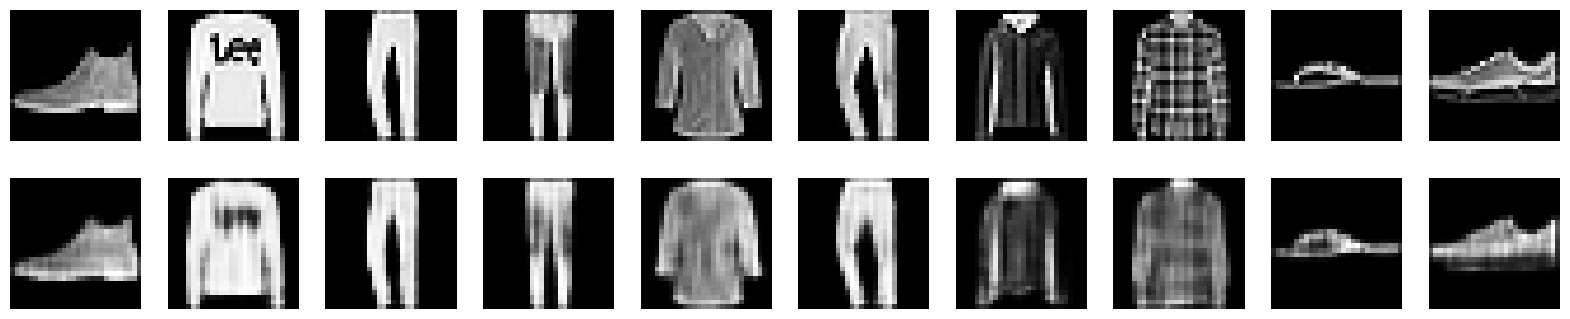

In [9]:
"""
6. Convolutional Autoencoder
Convolutional Autoencoders use convolutional layers to effectively capture spatial and hierarchical features in high-dimensional data such as images.
These models optimize reconstruction error using loss functions suited for images like mean squared error or binary cross-entropy.
The architecture helps in handling structured inputs by preserving spatial relationships.
"""

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

# if steel have not downloaded dataset uncomment and use this

# (x_train, _), (x_test, _) = fashion_mnist.load_data()
# x_train = x_train.astype('float32') / 255.
# x_test = x_test.astype('float32') / 255.

# x_train_flat = x_train.reshape(len(x_train), 784)
# x_test_flat = x_test.reshape(len(x_test), 784)

import os
import idx2numpy

data_dir = "./data/FashionMNIST/raw/"

x_train = idx2numpy.convert_from_file(os.path.join(data_dir, "train-images-idx3-ubyte"))
x_test  = idx2numpy.convert_from_file(os.path.join(data_dir, "t10k-images-idx3-ubyte"))

x_train = x_train.astype('float32') / 255.
x_test  = x_test.astype('float32') / 255.

x_train_flat = x_train.reshape(len(x_train), 784)
x_test_flat  = x_test.reshape(len(x_test), 784)


n = 10
input_img = tf.keras.Input(shape=(28, 28, 1))

x = tf.keras.layers.Conv2D(
    16, (3, 3), activation='relu', padding='same')(input_img)
x = tf.keras.layers.MaxPooling2D((2, 2), padding='same')(x)
x = tf.keras.layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
encoded = tf.keras.layers.MaxPooling2D((2, 2), padding='same')(x)

x = tf.keras.layers.Conv2D(
    8, (3, 3), activation='relu', padding='same')(encoded)
x = tf.keras.layers.UpSampling2D((2, 2))(x)
x = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = tf.keras.layers.UpSampling2D((2, 2))(x)
decoded = tf.keras.layers.Conv2D(
    1, (3, 3), activation='sigmoid', padding='same')(x)

conv_autoencoder = tf.keras.Model(input_img, decoded)
conv_autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)

conv_autoencoder.fit(x_train_cnn, x_train_cnn,
                     epochs=50,
                     batch_size=256,
                     shuffle=True,
                     validation_data=(x_test_cnn, x_test_cnn))

decoded_imgs = conv_autoencoder.predict(x_test_cnn)

plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_cnn[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.show()

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 38s 148ms/step - loss: 369.2408 - val_loss: 302.8879
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 35s 147ms/step - loss: 292.0865 - val_loss: 287.2520
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 35s 148ms/step - loss: 283.2287 - val_loss: 282.8968
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 35s 147ms/step - loss: 279.8352 - val_loss: 279.5259
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 35s 148ms/step - loss: 277.4102 - val_loss: 279.2169
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 35s 147ms/step - loss: 275.9449 - val_loss: 276.4097
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 35s 148ms/step - loss: 274.7285 - val_loss: 275.7987
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 35s 148ms/step - loss: 274.0595 - val_loss: 275.1217
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 35s 147ms/step - loss: 273.1005 - val_loss: 274.4751
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 34s 146ms/step - loss: 272.8395 - val_loss: 274.4107
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step


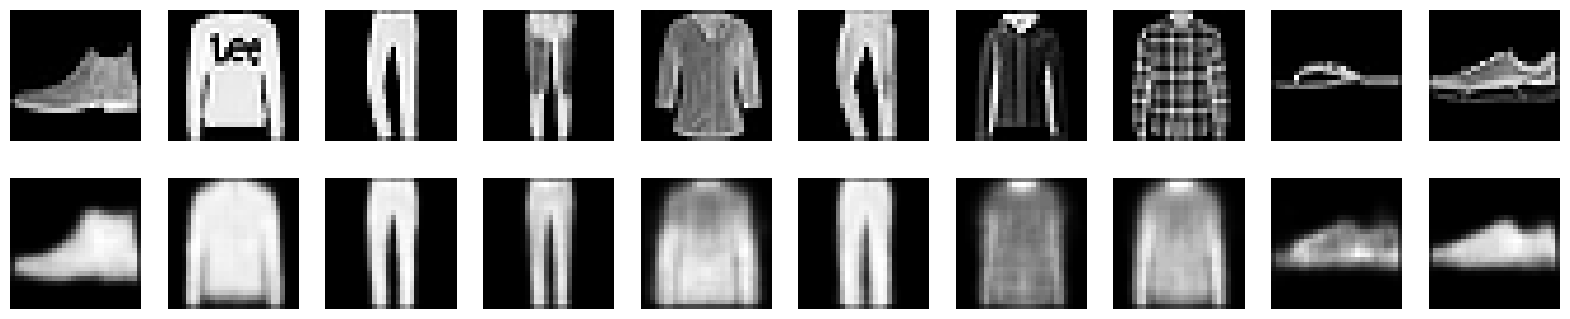

In [11]:
"""
7. Variational Autoencoder
Variational Autoencoder (VAEs) extend traditional autoencoders by learning probabilistic latent distributions instead of fixed representations. Training optimizes the Evidence Lower Bound (ELBO) which balances:

Reconstruction loss to ensure accurate data reconstruction.
KL Divergence to regularize the latent space towards a standard Gaussian helps in preventing overfitting and smooth latent structure.
"""

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.datasets import fashion_mnist


# if steel have not downloaded dataset uncomment and use this

# (x_train, _), (x_test, _) = fashion_mnist.load_data()
# x_train = x_train.astype('float32') / 255.
# x_test = x_test.astype('float32') / 255.
# x_train_cnn = x_train.reshape(-1, 28, 28, 1)
# x_test_cnn = x_test.reshape(-1, 28, 28, 1)

import os
import idx2numpy
import numpy as np

data_dir = "./data/FashionMNIST/raw/"

x_train = idx2numpy.convert_from_file(os.path.join(data_dir, "train-images-idx3-ubyte"))
x_test  = idx2numpy.convert_from_file(os.path.join(data_dir, "t10k-images-idx3-ubyte"))

x_train = x_train.astype('float32') / 255.
x_test  = x_test.astype('float32') / 255.

x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn  = x_test.reshape(-1, 28, 28, 1)


latent_dim = 2
n = 10

encoder_inputs = tf.keras.Input(shape=(28, 28, 1))
x = tf.keras.layers.Conv2D(32, 3, activation='relu',
                           strides=2, padding='same')(encoder_inputs)
x = tf.keras.layers.Conv2D(64, 3, activation='relu',
                           strides=2, padding='same')(x)
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(16, activation='relu')(x)
z_mean = tf.keras.layers.Dense(latent_dim)(x)
z_log_var = tf.keras.layers.Dense(latent_dim)(x)


def sampling(args):
    z_mean, z_log_var = args
    batch = tf.shape(z_mean)[0]
    dim = tf.shape(z_mean)[1]
    epsilon = tf.random.normal(shape=(batch, dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon


z = tf.keras.layers.Lambda(sampling)([z_mean, z_log_var])

encoder = tf.keras.Model(
    encoder_inputs, [z_mean, z_log_var, z], name='encoder')

latent_inputs = tf.keras.Input(shape=(latent_dim,))
x = tf.keras.layers.Dense(7 * 7 * 64, activation='relu')(latent_inputs)
x = tf.keras.layers.Reshape((7, 7, 64))(x)
x = tf.keras.layers.Conv2DTranspose(
    64, 3, strides=2, padding='same', activation='relu')(x)
x = tf.keras.layers.Conv2DTranspose(
    32, 3, strides=2, padding='same', activation='relu')(x)
decoder_outputs = tf.keras.layers.Conv2DTranspose(
    1, 3, padding='same', activation='sigmoid')(x)

decoder = tf.keras.Model(latent_inputs, decoder_outputs, name='decoder')

outputs = decoder(z)


class VAELossLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(VAELossLayer, self).__init__(**kwargs)

    def call(self, inputs):
        x, x_decoded, z_mean, z_log_var = inputs

        reconstruction_loss = tf.keras.losses.binary_crossentropy(
            K.flatten(x), K.flatten(x_decoded)
        )
        reconstruction_loss *= 28 * 28

        kl_loss = 1 + z_log_var - K.square(z_mean) - K.exp(z_log_var)
        kl_loss = K.sum(kl_loss, axis=-1)
        kl_loss *= -0.5

        total_loss = K.mean(reconstruction_loss + kl_loss)
        self.add_loss(total_loss)
        return x_decoded


outputs_with_loss = VAELossLayer()(
    [encoder_inputs, outputs, z_mean, z_log_var])

vae = tf.keras.Model(encoder_inputs, outputs_with_loss, name='vae_with_loss')

vae.compile(optimizer='adam')

# if have gpu change epochs to 50
vae.fit(x_train_cnn, epochs=10, batch_size=256,
        validation_data=(x_test_cnn, None))

decoded_imgs = vae.predict(x_test_cnn)

plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_cnn[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.show()